This is a tutorial on how to use this 2D FMM RCWA code.

In [1]:
import RCWA_project.classes as classes
import RCWA_project.core as core
import numpy as np
import matplotlib.pyplot as plt

# Simple imports

In [2]:
# Computation parameters: nb of modes and stretching coefficient
Mm = 151
# Nm = 8
# eta = 0.999 # between 0 and 1 (but never exactly 1) Empirically, very close to 1 works really well

# Structure parameters: size of a MIM resonator
hcube = 70.0               # height of the cube
hspacer = 1.0            # height of the spacer
l_cubex = 70.0           # cube width along axis x
hgold = 500.0
# l_cubey = 70.0           # cube width along axis y
period = 300.1/2
space_x = (period-l_cubex)     # period along x (RCWA nerd advice, never use an exactly round period)
# space_y = 300-l_cubey     # period along x (RCWA nerd advice, never use an exactly round period)

eps_dielec = 1.0**2        # spacer permittivity
metal_perm = "Gold"   # metal permittivity


In [ ]:
pmlx=[0, 0]
interfacesx = [0, space_x, space_x+l_cubex, 2*space_x+l_cubex]
print(interfacesx)
# nx = [0,l_cubex,l_cubex+space_x]

Air = classes.Material(1.0)
SiO2 = classes.Material(eps_dielec)
Gold = classes.Material(metal_perm)

print(Gold.get_permittivity(1300))

# The top layer (air)
top_layer =  np.array([Air,Air,Air])
# The substrate layer (gold)
gold_layer =  np.array([Gold,Gold,Gold])
# The substrate layer (gold)
spacer_layer =  np.array([Air,Air,Air])
# The spacer layer (dielectric)
bot_layer =  np.array([SiO2,SiO2,SiO2])
# The cube layer, structured
gp_layer = np.array([Air, Gold,Air])

layers = [top_layer, gp_layer, spacer_layer, gold_layer]#, bot_layer]
thicknesses = [0, hcube, hspacer, 0]
homo_layer = [1, 0, 1, 1]#, 1]
pmls = pmlx
structure = classes.Structure(layers, thicknesses, interfacesx, homo_layer, pmls)


interfacesy = [0, 1.02]
# The top layer (air)
top_layer =  np.array([top_layer])
# The substrate layer (gold)
gold_layer =  np.array([gold_layer])
# The substrate layer (gold)
spacer_layer =  np.array([spacer_layer])
# The spacer layer (dielectric)
bot_layer =  np.array([bot_layer])
# The cube layer, structured
gp_layer = np.array([gp_layer])

pmls = [[0,0,0], [0]]
layers = [top_layer, gp_layer, spacer_layer, gold_layer]#, bot_layer]
structure2D = classes.Structure(layers, thicknesses, [interfacesx, interfacesy], homo_layer, pmls)

[0, 80.05000000000001, 150.05, 230.10000000000002]
(-67+7j)


500.0
522.4530612244898
544.9061224489795
567.3591836734694
589.8122448979592
612.265306122449
634.7183673469387
657.1714285714286
679.6244897959184
702.0775510204082
724.530612244898
746.9836734693878
769.4367346938775
791.8897959183673
814.3428571428572
836.795918367347
859.2489795918368
881.7020408163265
904.1551020408164
926.6081632653061
949.0612244897959
971.5142857142857
993.9673469387756
1016.4204081632654
1038.873469387755
1061.3265306122448
1083.7795918367347
1106.2326530612245
1128.6857142857143
1151.1387755102041
1173.591836734694
1196.0448979591838
1218.4979591836736
1240.9510204081635
1263.404081632653
1285.857142857143
1308.3102040816327
1330.7632653061225
1353.2163265306122
1375.669387755102
1398.1224489795918
1420.5755102040816
1443.0285714285715
1465.4816326530613
1487.9346938775511
1510.387755102041
1532.8408163265308
1555.2938775510204
1577.7469387755102
1600.2


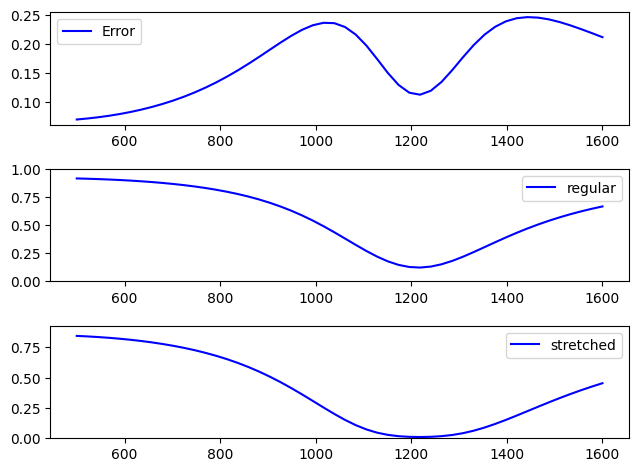

In [ ]:
Rs = []
Ts = []
Rs_eta = []
Ts_eta = []
modes = 34
theta = 0.01 * np.pi/180.
pol = 1
incidence = [theta, pol]
# Incidence parameters
lambdas = np.linspace(500, 1600.2, 50) # Being a 3D simulation, each point in parameter space can take a few seconds on a reasonable computer
for i, lambd in enumerate(lambdas):
    print(lambd)
    R, T = core.coefficient_2D(structure2D, lambd, [theta,0,0], [16,0], pmls, eta=0.99)
    Rs_eta.append(R)
    Ts_eta.append(T)
    R, T = core.coefficient_1D(structure, lambd, incidence, 50, eta=0.0)
    Rs.append(R)
    Ts.append(T)
    # Now that everything is defined, we can compute the modes in each structure!

plt.subplot(3,1,1)
plt.plot(lambdas, (np.array(Rs)-np.array(Rs_eta)), 'b', label="Error")
plt.legend()
plt.subplot(3,1,2)
plt.plot(lambdas, np.array(Rs), 'b', label="regular")
plt.ylim([0,1])
plt.legend()
plt.subplot(3,1,3)
plt.plot(lambdas, np.array(Rs_eta), 'b', label="stretched")
plt.ylim([0,1.1*np.max(Rs_eta)])
plt.legend()
plt.tight_layout()

In [5]:
print(np.array(Rs) - np.array(Rs_eta))

[0.06895547 0.11735055 0.21466034 0.24721613 0.21895173 0.18279833
 0.13875061 0.11931499 0.11845774 0.14906497 0.1423529  0.09526681
 0.07688302 0.06941154 0.06602391 0.06441198 0.0633506  0.06299963
 0.06362748 0.0650533  0.06727837 0.07040181 0.07454618 0.07999693
 0.08703242 0.09603017 0.10769702 0.12293689 0.14266681 0.16764001
 0.19733941 0.22679518 0.23970879 0.20880772 0.1445451  0.14165395
 0.20745784 0.24575802 0.23779968 0.20984301 0.17965494 0.15338216
 0.13203543 0.11505909 0.1015895  0.09082409 0.08212727 0.07503142
 0.06918265 0.06430387]


In [ ]:
pmlx=[0, 0, 0]
interfacesx = [0, space_x, space_x+l_cubex, 2*space_x+l_cubex]
# nx = [0,l_cubex,l_cubex+space_x]

Air = classes.Material(1.0)
SiO2 = classes.Material(eps_dielec)
Gold = classes.Material(metal_perm)

# The top layer (air)
top_layer =  np.array([Air,Air,Air])
# The substrate layer (gold)
gold_layer =  np.array([Gold,Gold,Gold])
# The substrate layer (gold)
spacer_layer =  np.array([Air,Air,Air])
pmls = pmlx
# The spacer layer (dielectric)
bot_layer =  np.array([SiO2,SiO2,SiO2])
# The cube layer, structured
gp_layer = np.array([Air, Gold,Air])
layers = [top_layer, gp_layer, spacer_layer, gold_layer]#, bot_layer]
thicknesses = [40, hcube, hspacer, 40]
homo_layer = [1, 0, 1, 1]#, 1]
structure = classes.Structure(layers, thicknesses, interfacesx, homo_layer, pmlx)

zres = 0.1
xres = 0.5
x, z, map = core.compute_field_1D(structure, 700, incidence, zres, xres, 100)#, eta=0.5)


sizes [400. 700.  10. 400.] 460


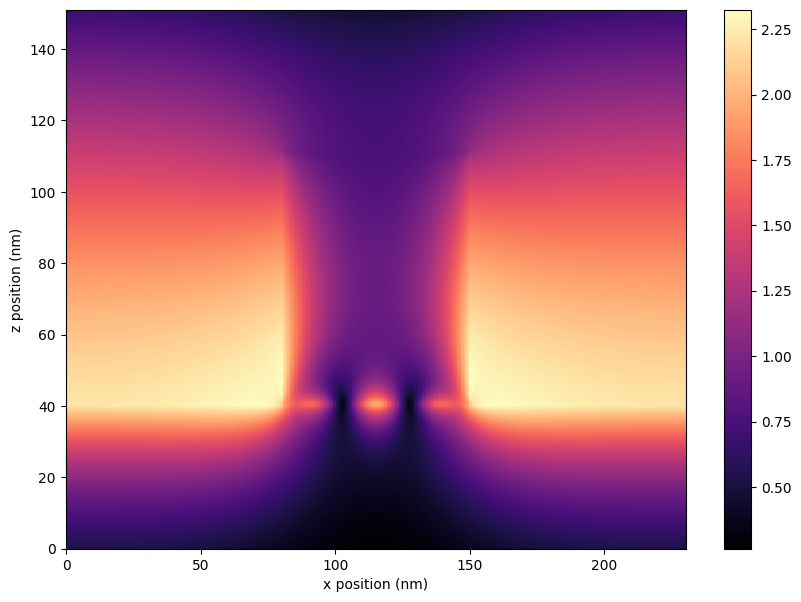

In [10]:

plt.figure(figsize=(10, 7))
plt.pcolor(x, z, np.abs(map), cmap="magma")
plt.xlabel('x position (nm)')
plt.ylabel('z position (nm)')
plt.colorbar()
plt.savefig("mine_RCWA/Field_map_3rdOrder_70nmCube_1nmGap.png")

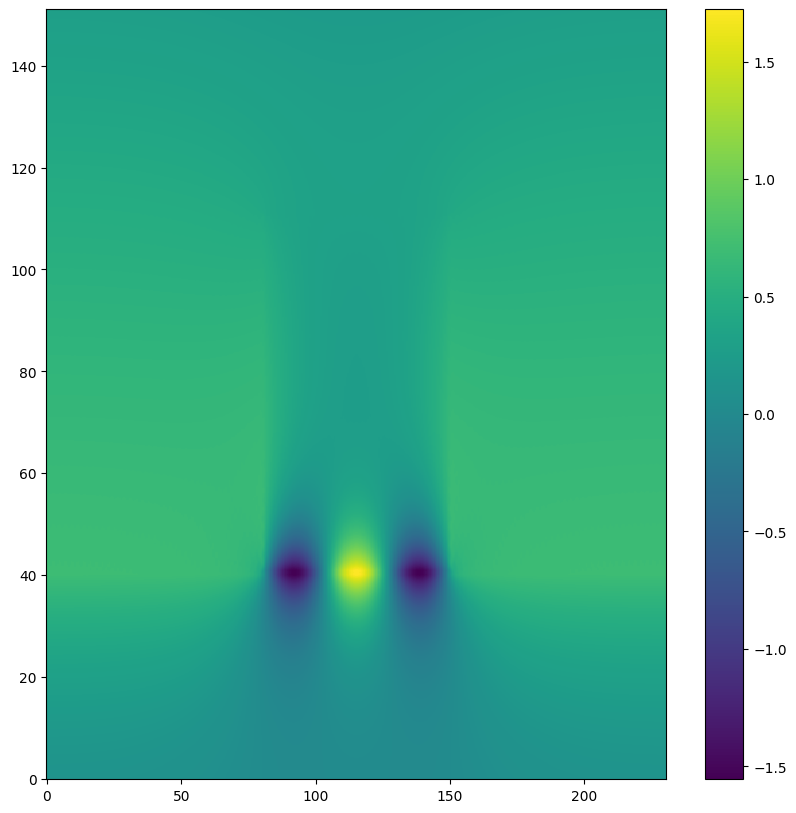

In [11]:
plt.figure(figsize=(10, 10))
plt.pcolor(x, z, np.real(map), cmap="viridis")
plt.colorbar()